In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("smartcart_customers.csv")

In [3]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [4]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

# Data preprocessing

## 1.Handle Missing Values 

In [5]:
df["Income"]=df["Income"].fillna(df["Income"].median())

In [6]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

## 2.Feature Engineering

In [7]:
df["Age"]=2026-df["Year_Birth"]

In [8]:
df["Dt_Customer"]=pd.to_datetime(df["Dt_Customer"],dayfirst=True)

reference=df["Dt_Customer"].max()

df["Customer_Tenure_Days"]=(reference-df["Dt_Customer"]).dt.days #total numbers of days

In [9]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_Days'],
      dtype='object')

In [10]:
df["Total_Spending"]=df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]

In [11]:
df["Total_Children"]=df["Kidhome"] + df["Teenhome"]

In [12]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,8,10,4,7,0,1,69,663,1617,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,1,1,2,5,0,0,72,113,27,2
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,8,2,10,4,0,0,61,312,776,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,0,4,6,0,0,42,139,53,1
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,3,6,5,0,0,45,161,422,1


In [13]:
#Education
df["Education"].value_counts()

df["Education"]=df["Education"].replace({
   "Basic":"Undergraduate","2n Cycle":"Undergraduate","Graduation":"Graduate","Master":"Postgraduate",
    "PhD":"Postgraduate"
})

In [14]:
#Marital Status
df["Living_With"]=df["Marital_Status"].replace({
   "Married":"Partner","Together":"Partner","Single":"Alone","Divorced":"Alone","Widow":"Alone",
    "Alone":"Alone","Absurd":"Alone","YOLO":"Alone"
})

#df["Living_With"].value_counts()

## Drop columns

In [15]:
cols=["ID","Year_Birth","Marital_Status","Kidhome","Teenhome","Dt_Customer","MntWines","MntFruits",
     "MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]

df_cleaned=df.drop(columns=cols)

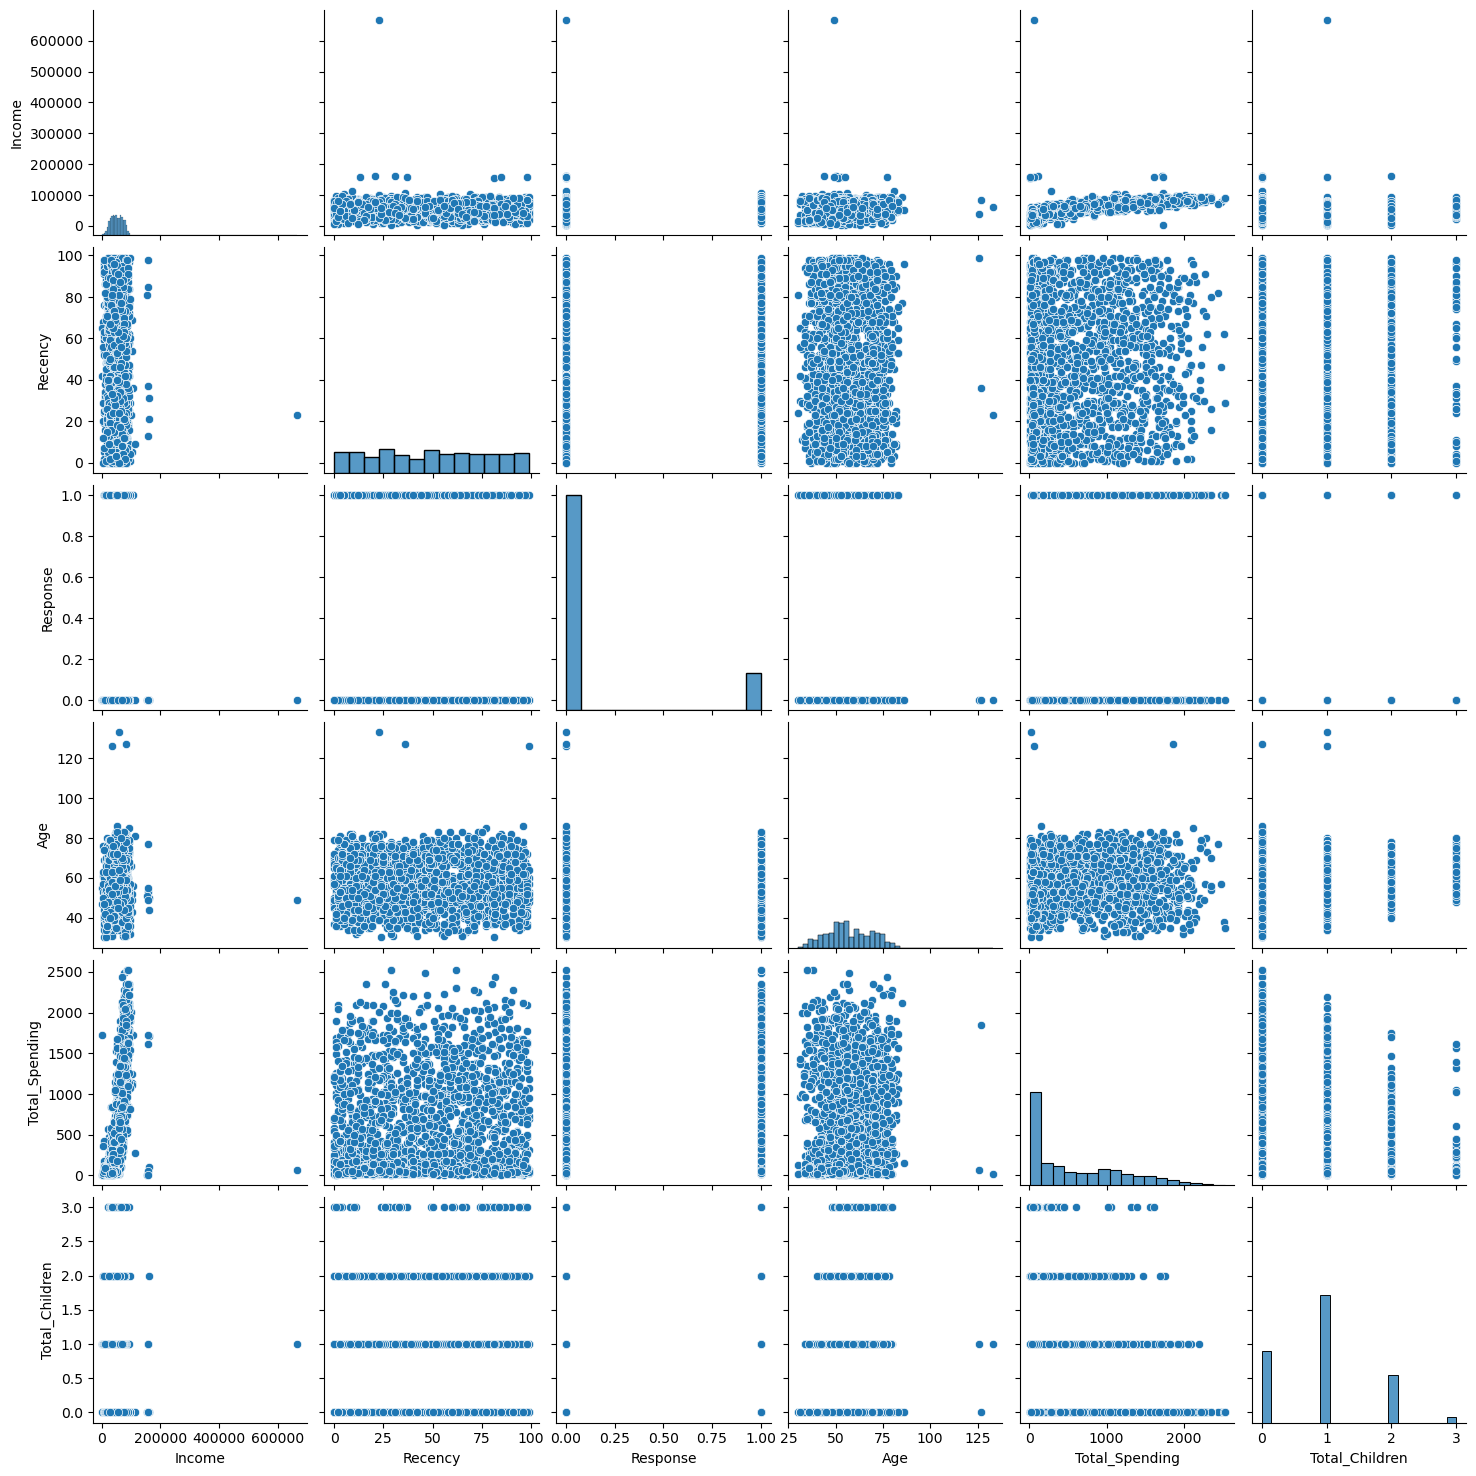

In [16]:
cols=["Income","Recency","Response","Age","Total_Spending","Total_Children"]

sns.pairplot(df_cleaned[cols])

In [17]:
# Remove outlier
print("data size with outlies",len(df_cleaned))
df_cleaned=df_cleaned[(df_cleaned["Age"]<90)]
df_cleaned=df_cleaned[(df_cleaned["Income"]<600_000)]
print("data size without outlies",len(df_cleaned))

data size with outlies 2240
data size without outlies 2236


In [18]:
# Heatmap

corr=df_cleaned.corr(numeric_only=True)

<Axes: >

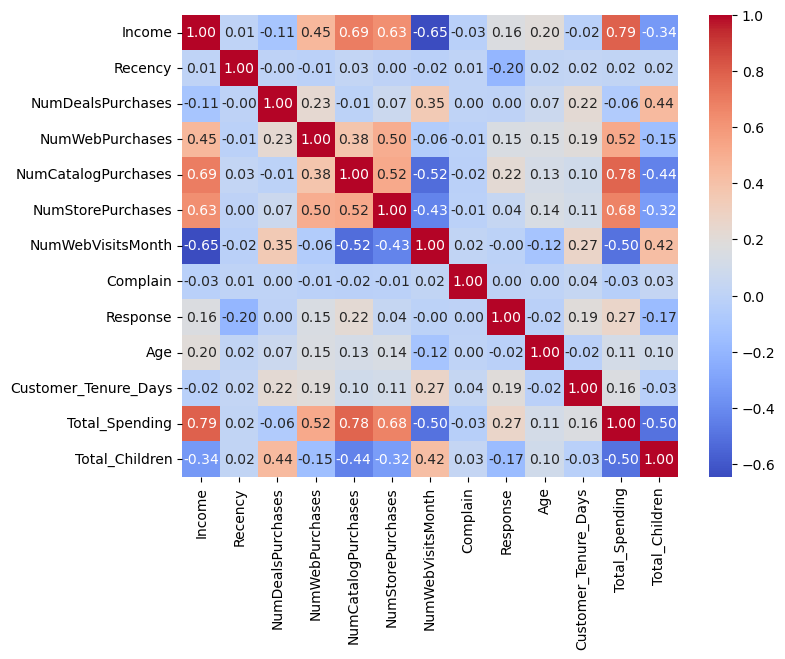

In [19]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

In [20]:
df_cleaned.shape

(2236, 15)

# 2.Encoding

In [21]:
from sklearn.preprocessing import OneHotEncoder

In [22]:
ohe=OneHotEncoder()

cat_col=["Education","Living_With"]
enco_col=ohe.fit_transform(df_cleaned[cat_col])

enc_df=pd.DataFrame(enco_col.toarray(),columns=ohe.get_feature_names_out(cat_col),index=df_cleaned.index)

In [23]:
df_encoded=pd.concat([df_cleaned.drop(columns=cat_col),enc_df],axis=1)

In [24]:
X=df_encoded

### scalling

In [25]:
from sklearn.preprocessing import StandardScaler

In [26]:
scaler=StandardScaler()

X_scal=scaler.fit_transform(X)

# 3.Visualize

In [27]:
from sklearn.decomposition import PCA

In [28]:
pca=PCA(n_components=3)

X_pca=pca.fit_transform(X_scal)

In [29]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

Text(0.5, 0.92, '3d projection')

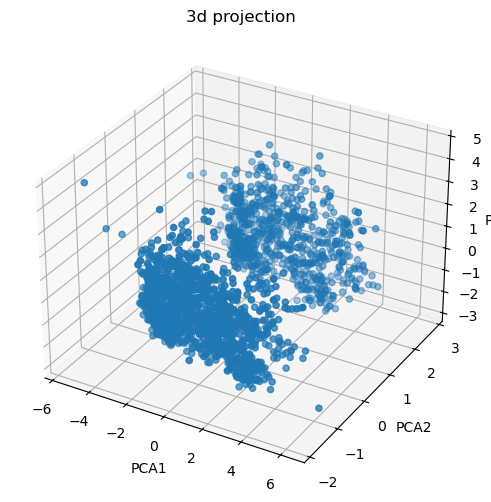

In [30]:
fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection="3d")

ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2])
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3d projection")

In [31]:
# Analyze K value 
from sklearn.cluster import KMeans


wcss=[]

for k in range(1,11):
    kmean=KMeans(n_clusters=k,random_state=42)
    kmean.fit_predict(X_pca)
    wcss.append(kmean.inertia_)

In [32]:
from kneed import KneeLocator

knee=KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")

In [33]:
print(f"k is :{knee.knee}")

k is :4


Text(0, 0.5, 'WCSS')

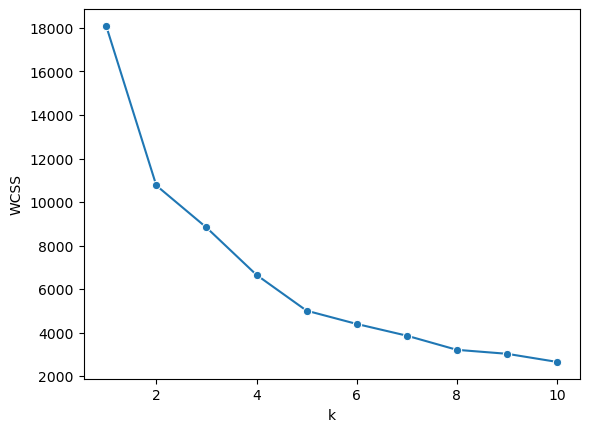

In [34]:
sns.lineplot(x=range(1,11),y=wcss,marker='o')
plt.xlabel("k")
plt.ylabel("WCSS")

In [35]:
from sklearn.metrics import silhouette_score

scores=[]

for k in range(2,11):
    kmean=KMeans(n_clusters=k,random_state=42)
    labels=kmean.fit_predict(X_pca)
    score=silhouette_score(X_pca,labels)
    scores.append(score)

Text(0, 0.5, 'Silhouette score')

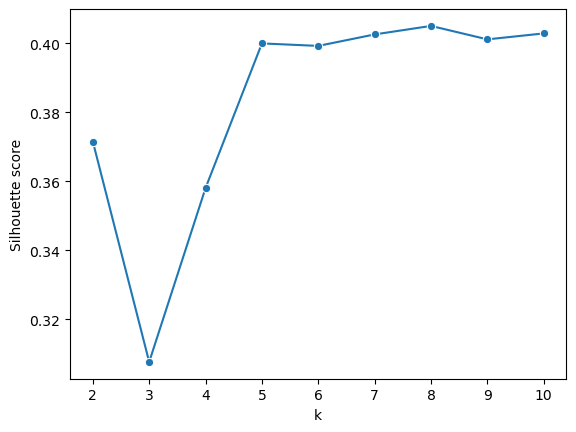

In [36]:
sns.lineplot(x=range(2,11),y=scores,marker='o')
plt.xlabel("k")
plt.ylabel("Silhouette score")

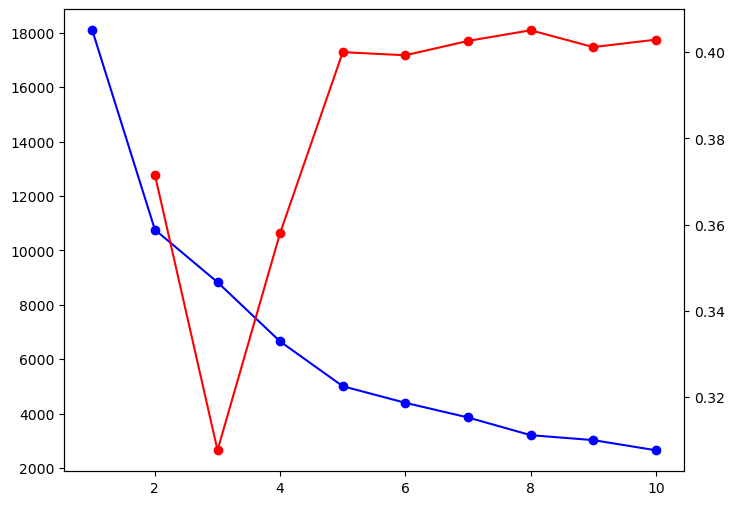

In [37]:
fig,ax1=plt.subplots(figsize=(8,6))

ax1.plot(range(1,11),wcss,marker='o',color='blue')
ax2=ax1.twinx()
ax2.plot(range(2,11),scores,marker='o',color='red')

# 4.Clustering

Text(0.5, 0.92, '3d projection')

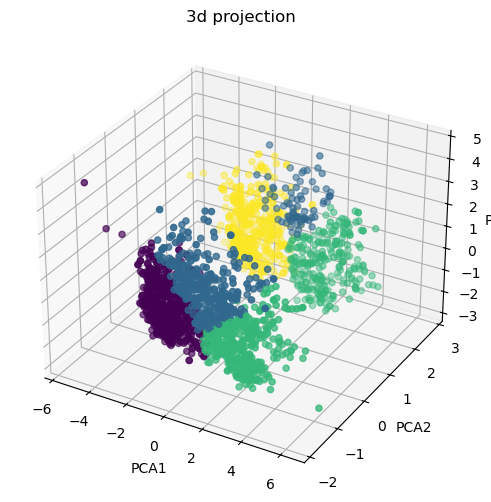

In [38]:
kmean=KMeans(n_clusters=4,random_state=42)

labels=kmean.fit_predict(X_pca)

fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection="3d")

ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=labels)
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3d projection")

In [39]:
from sklearn.cluster import AgglomerativeClustering

Text(0.5, 0.92, '3d projection')

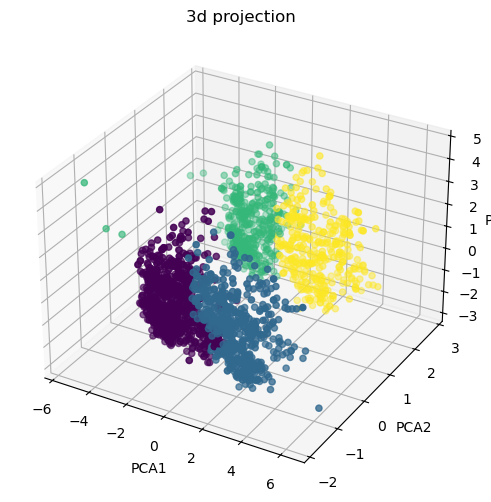

In [40]:
agg=AgglomerativeClustering(n_clusters=4,linkage='ward')

labels_agg=agg.fit_predict(X_pca)

fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection="3d")

ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=labels_agg)
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3d projection")

# Characterization

In [50]:
X["clusters"]=labels_agg

In [51]:
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner,clusters
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0


<Axes: xlabel='clusters', ylabel='count'>

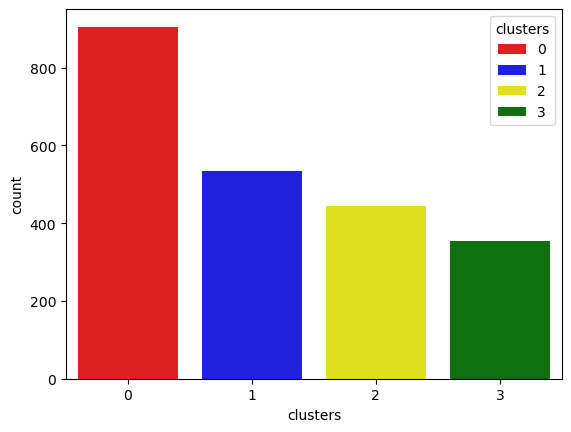

In [52]:
pal=["red","blue","yellow","green"]

sns.countplot(x=X["clusters"],palette=pal,hue=X["clusters"])

<Axes: xlabel='Total_Spending', ylabel='Income'>

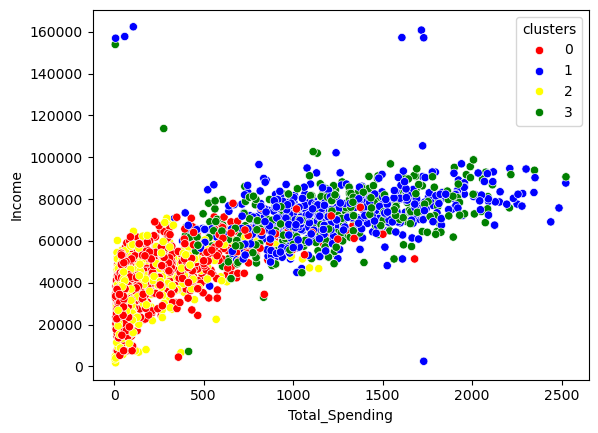

In [53]:
sns.scatterplot(x=X["Total_Spending"],y=X["Income"],hue=X["clusters"],palette=pal)

In [55]:
cluster_summary=X.groupby("clusters").mean()

print(cluster_summary)

                Income    Recency  NumDealsPurchases  NumWebPurchases  \
clusters                                                                
0         39680.580110  48.914917           2.594475         3.153591   
1         72808.445693  49.202247           1.958801         5.687266   
2         36960.143018  48.319820           2.594595         2.713964   
3         70722.681303  50.504249           1.855524         5.790368   

          NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
clusters                                                                        
0                    0.969061           4.143646           6.307182  0.011050   
1                    5.498127           8.659176           3.580524  0.005618   
2                    0.837838           3.623874           6.659910  0.011261   
3                    5.014164           8.430595           3.728045  0.005666   

          Response        Age  Customer_Tenure_Days  Total_Spending  \
clu